In [17]:
import os
os.chdir(r'c:\\Users\\moons\\OneDrive\\Documents\\polymorph_revised\\polymorphism')
os.getcwd()

'c:\\Users\\moons\\OneDrive\\Documents\\polymorph_revised\\polymorphism'

In [22]:
df2['mp_id']

0         cifs/mp-10000.cif
1         cifs/mp-10003.cif
2         cifs/mp-10004.cif
3         cifs/mp-10006.cif
4         cifs/mp-10008.cif
                ...        
55096    cifs/mp-999566.cif
55097    cifs/mp-999576.cif
55098      cifs/mp-9996.cif
55099      cifs/mp-9998.cif
55100      cifs/mp-9999.cif
Name: mp_id, Length: 51877, dtype: object

In [2]:
import pandas as pd

df2 = pd.read_csv('dataset/dataset.csv')
# Normalize mp_id to match cif file paths used elsewhere
# df['mp_id'] = df['mp_id'].astype(str).apply(lambda x: f"cifs/{x}.cif")

# # Read main dataset
# df2 = pd.read_csv('dataset/dataset.csv')

# # Merge energy_above_hull into df2 by mp_id
# df2 = df2.merge(df[['mp_id', 'energy_above_hull']], on='mp_id', how='left')

# print('df2 shape:', df2.shape)
# print('Missing energy values:', df2['energy_above_hull'].isna().sum())

# print(df.shape)

# ids=df['mp_id'].tolist()
# df2=df2[df2['mp_id'].isin(ids)]
print(df2.shape)

## removing the unstable structures

# df2=df2[df2['energy_above_hull']<=0.1]
# print('Final dimension: ',df2.shape)



(56917, 17)


In [3]:
from pymatgen.core import Structure
from pymatgen.analysis.structure_matcher import StructureMatcher
from pathlib import Path

# Deduplicate structures for each formula
matcher = StructureMatcher(ltol=0.2, stol=0.3, angle_tol=5, primitive_cell=True)
unique_formulas = df2['reduced_formula'].unique()
cif_base_dir = Path(r"C:\Users\moons\OneDrive\Documents\spring25\mp cifs\drive-download-20250114T195716Z-001\cifs\cifs")

deduplicated_mp_ids = []
total_removed = 0

for formula in unique_formulas:
    formula_df = df2[df2['reduced_formula'] == formula]
    mp_ids = formula_df['mp_id'].tolist()
    
    if len(mp_ids) == 1:
        deduplicated_mp_ids.append(mp_ids[0])
        continue
    
    # Load structures
    structures = []
    valid_mp_ids = []
    for mp_id in mp_ids:
        cif_file = mp_id.split('/')[1]  # Extract mp-xxx.cif from cifs/mp-xxx.cif
        cif_path = cif_base_dir / cif_file
        try:
            struct = Structure.from_file(str(cif_path))
            structures.append(struct)
            valid_mp_ids.append(mp_id)
        except Exception as e:
            pass
    
    if len(structures) == 0:
        continue
    
    # Group similar structures
    groups = matcher.group_structures(structures)
    removed = len(structures) - len(groups)
    total_removed += removed
    
    # Keep one representative from each group
    for group in groups:
        first_struct = group[0]
        idx = structures.index(first_struct)
        deduplicated_mp_ids.append(valid_mp_ids[idx])

# Filter df2 to keep only deduplicated structures
df2 = df2[df2['mp_id'].isin(deduplicated_mp_ids)]




c:\Users\moons\anaconda3\Lib\site-packages\pymatgen\core\structure.py:3087: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
c:\Users\moons\anaconda3\Lib\site-packages\pymatgen\core\structure.py:3087: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
c:\Users\moons\anaconda3\Lib\site-packages\pymatgen\core\structure.py:3087: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
c:\Users\moons\anaconda3\Lib\site-packages\pymatgen\core\structure.py:3087: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values t

In [10]:
import pandas as pd
df2=pd.read_csv('dataset/dataset_polymorphs_deduped.csv')
df2.shape

(16999, 17)

In [6]:
print(f'After deduplication: {df2.shape}')
print(f'Total duplicates removed: {total_removed}')

After deduplication: (55409, 17)
Total duplicates removed: 1508


In [50]:
 df2.columns

Index(['mp_id', 'reduced_formula', 'atoms', 'polymorphs', 'elements', 'sg',
       'sg_num', 'packing_density', 'occupied_volume', 'unit_cell_volume',
       'perovskite', 'polyhedron', 'cn', 'binary', 'ternary', 'prototype',
       'ox_state', 'energy_above_hull'],
      dtype='object')

# Prototype labeling

In [7]:
from pymatgen.core import Composition
from math import gcd
from functools import reduce

def _gcd_list(ints):
    return reduce(gcd, ints) if ints else 1

def normalize_counts(counts):
    """
    counts: iterable of positive numbers (floats or ints)
    returns: list of ints with smallest element = 1 (or smallest integer divisor removed)
    """
    # convert to ints if all are very near integers, otherwise scale to small ints
    # first round small floating noise
    rounded = [int(round(c)) for c in counts]
    # if any are zero or negative, fallback
    if any(x <= 0 for x in rounded):
        rounded = [max(1, int(round(c))) for c in counts]
    g = _gcd_list(rounded)
    return [x // g for x in rounded]

def classify_prototype(formula):
    comp = Composition(formula)
    el_amt = comp.get_el_amt_dict()  # e.g. {'Ca': 1.0, 'Ti': 1.0, 'O': 3.0}
    num_elements = len(el_amt)
    counts = list(el_amt.values())
    norm = sorted(normalize_counts(counts))

    # 2-element cases
    if num_elements == 2:
        if norm == [1, 1]:
            return 'Rocksalt/Zincblende/CsCl'
        elif norm == [1, 2]:
            # covers both AB2 and A2B after normalization (sorted gives [1,2])
            return 'Fluorite/Rutile'
        else:
            return 'Binary'

    # 3-element cases
    elif num_elements == 3:
        # Perovskite ABO3 -> [1,1,3] after normalization
        if norm == [1, 1, 3]:
            return 'Perovskite'
        # Spinel AB2X4 -> [1,2,4] after normalization
        if norm == [1, 2, 4]:
            return 'Spinel'
        return 'Ternary'

    # 4-element cases
    elif num_elements == 4:
        return 'Quaternary'

    else:
        return 'Other'


In [11]:
df2['prototype'] = df2['reduced_formula'].apply(classify_prototype)
df2.to_csv('dataset/dataset_polymorphs_deduped.csv', index=False)

In [4]:
import pandas as pd
df2=pd.read_csv('dataset/dataset_polymorphs_deduped.csv')

In [9]:
df2['prototype'].value_counts()

prototype
Ternary                     6409
Binary                      3093
Quaternary                  2196
Fluorite/Rutile             1764
Rocksalt/Zincblende/CsCl    1407
Perovskite                  1129
Spinel                       676
Other                        325
Name: count, dtype: int64

In [6]:
df2['prototype'].value_counts()

prototype
Ternary                     7085
Binary                      3108
Quaternary                  2196
Fluorite/Rutile             1764
Rocksalt/Zincblende/CsCl    1392
Perovskite                  1129
Other                        325
Name: count, dtype: int64

In [5]:
# Create df3 with only polymorphic formulas (reduced_formula count > 1)
vc = df2['reduced_formula'].value_counts()
polymorphic_formulas = vc[vc > 1].index
df3 = df2[df2['reduced_formula'].isin(polymorphic_formulas)]


# df3=df3[df3['energy_above_hull']<=0.1]

print(f'df3 shape: {df3.shape}')
print(f'Number of unique polymorphic formulas: {df3["reduced_formula"].nunique()}')
print(f'Total structures in polymorphic formulas: {len(df3)}')


df3 shape: (16999, 17)
Number of unique polymorphic formulas: 5745
Total structures in polymorphic formulas: 16999


In [14]:
df3.to_csv('dataset/dataset_polymorphs_deduped.csv', index=False)

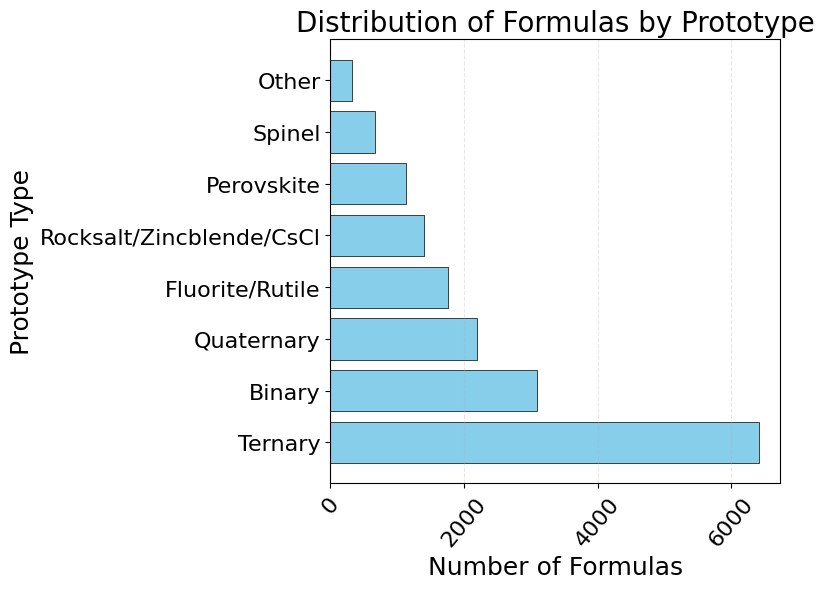

Total prototypes: 8


In [6]:
import matplotlib.pyplot as plt

# Count formulas by prototype
prototype_counts = df3['prototype'].value_counts()

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(prototype_counts.index, prototype_counts.values, color='skyblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Formulas', fontsize=18)
ax.set_ylabel('Prototype Type', fontsize=18)
ax.set_title('Distribution of Formulas by Prototype', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
plt.xticks(rotation=50)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('ov.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total prototypes: {len(prototype_counts)}')


In [ ]:
df3['elements']

0               ['Hf', 'S']
1        ['Nb', 'Co', 'Si']
2               ['Mo', 'P']
3        ['Tl', 'Ag', 'Te']
4              ['Ca', 'Ge']
                ...        
55096    ['Mn', 'Cu', 'Sb']
55097    ['Mn', 'Si', 'Ru']
55098           ['Si', 'P']
55099          ['Mo', 'As']
55100     ['Ni', 'B', 'Mo']
Name: elements, Length: 49282, dtype: object

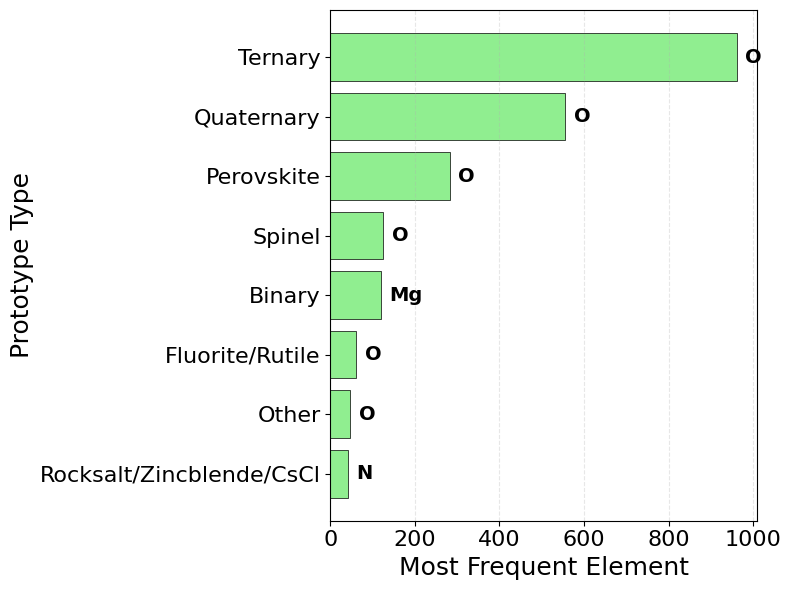

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

# For each prototype, find the most frequent element across all formulas
prototype_element_data = []

for prototype in df3['prototype'].unique():
    subset = df3[df3['prototype'] == prototype]
    
    # For each unique formula in this prototype, get unique elements
    all_elements = []
    for formula in subset['reduced_formula'].unique():
        formula_rows = subset[subset['reduced_formula'] == formula]
        # Get elements from first row of this formula (all rows have same elements for same formula)
        elements_str = formula_rows['elements'].iloc[0]
        unique_elements = set(eval(elements_str))
        all_elements.extend(unique_elements)
    
    # Count most frequent element across all formulas in this prototype
    most_common = Counter(all_elements).most_common(1)
    if most_common:
        element, count = most_common[0]
        prototype_element_data.append((prototype, element, count))

# Sort by count
prototype_element_data.sort(key=lambda x: x[2])

# Prepare data for plotting
prototypes = [x[0] for x in prototype_element_data]
elements = [x[1] for x in prototype_element_data]
counts = [x[2] for x in prototype_element_data]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(prototypes, counts, color='lightgreen', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Most Frequent Element', fontsize=18)
ax.set_ylabel('Prototype Type', fontsize=18)
ax.tick_params(axis='both', labelsize=16)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add element labels on bars
for i, (bar, element) in enumerate(zip(bars, elements)):
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2, element, 
            ha='left', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('overleaf_prototype.png', dpi=300, bbox_inches='tight')
plt.show()


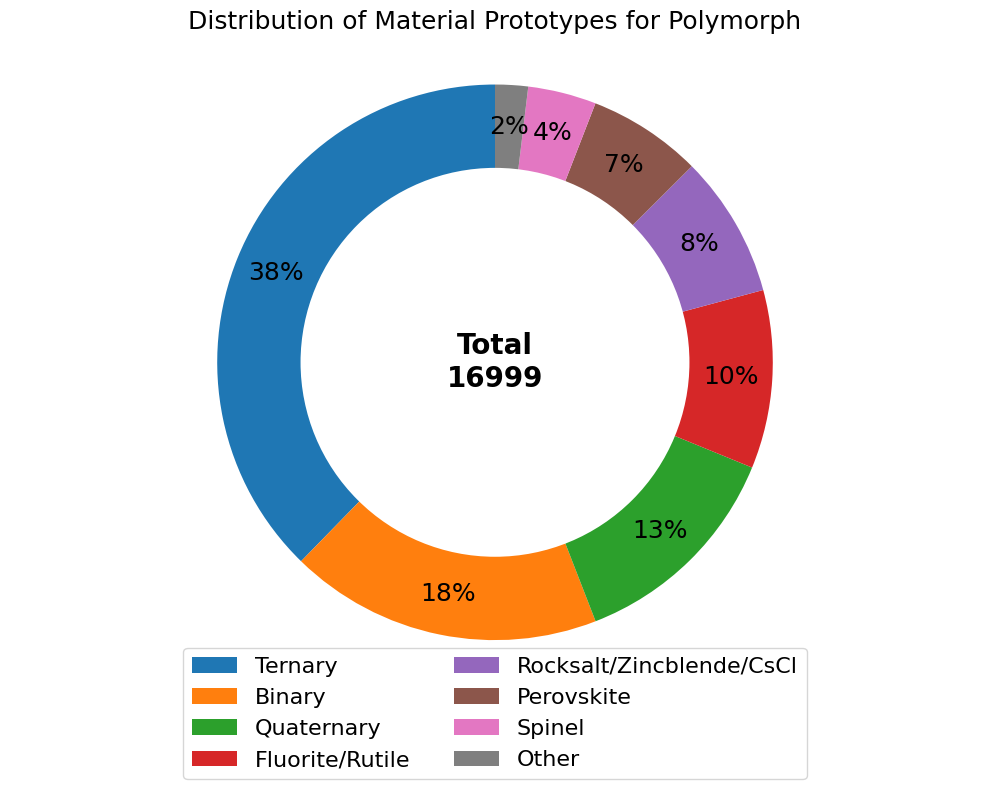

Total structures in polymorphic formulas: 16999

Breakdown by prototype:
Ternary: 6409 (38%)
Binary: 3093 (18%)
Quaternary: 2196 (13%)
Fluorite/Rutile: 1764 (10%)
Rocksalt/Zincblende/CsCl: 1407 (8%)
Perovskite: 1129 (7%)
Spinel: 676 (4%)
Other: 325 (2%)


In [16]:
import matplotlib.pyplot as plt

# Count prototypes in df3
prototype_counts = df3['prototype'].value_counts()
total = len(df3)

# Create color map
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# Create donut chart
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(prototype_counts.values, 
                                    labels=None,
                                    autopct='%1.0f%%',
                                    startangle=90,
                                    colors=colors[:len(prototype_counts)],
                                    pctdistance=0.85,
                                    textprops={'fontsize': 18})

# Draw circle to make it a donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add total in center
ax.text(0, 0, f'Total\n{total}', ha='center', va='center', fontsize=20, fontweight='bold')

# Title
ax.set_title('Distribution of Material Prototypes for Polymorph', fontsize=18, pad=20)

# Add legend below the plot
ax.legend(wedges, prototype_counts.index, title="", loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=16)

# Equal aspect ratio ensures circular shape
ax.axis('equal')

plt.tight_layout()
plt.savefig('ov2.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total structures in polymorphic formulas: {total}')
print(f'\nBreakdown by prototype:')
for proto, count in prototype_counts.items():
    print(f'{proto}: {count} ({round(count/total*100)}%)')